# Benchmark de frames en Drive: Original vs Splatfacto vs Nerfacto

Este notebook compara tres datasets de imágenes guardados en Google Drive:

```text
/colab
  benchmark_frames_drive_real_vs_splatfacto_nerfacto.ipynb
  /datasets
    /original
    /splatfacto
    /nerfacto
```

El notebook elige una muestra aleatoria o uniforme de frames y calcula **PSNR, SSIM, LPIPS, MSE y MAE**.

> Para que PSNR/SSIM/LPIPS sean válidos, los frames de `splatfacto` y `nerfacto` deberían corresponder a la misma cámara/frame que los de `original`.

In [18]:
!pip -q install lpips scikit-image pandas matplotlib opencv-python tqdm pillow
!pip -q install reportlab

import os, re, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

import torch
import lpips

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


## 1. Montar Google Drive

Ajustá `PROJECT_DIR` si tu carpeta `/colab` está en otra ruta.

In [19]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/")
DATASETS_DIR = PROJECT_DIR / "datasets"

ORIGINAL_DIR = DATASETS_DIR / "original"
SPLATFACTO_DIR = DATASETS_DIR / "splatfacto"
NERFACTO_DIR = DATASETS_DIR / "nerfacto"

OUTPUT_DIR = PROJECT_DIR / "benchmark_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for name, path in {
    "project": PROJECT_DIR,
    "datasets": DATASETS_DIR,
    "original": ORIGINAL_DIR,
    "splatfacto": SPLATFACTO_DIR,
    "nerfacto": NERFACTO_DIR,
    "output": OUTPUT_DIR,
}.items():
    print(f"{name:10s} → {path} | exists: {path.exists()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
project    → /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks | exists: True
datasets   → /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets | exists: True
original   → /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets/original | exists: True
splatfacto → /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets/splatfacto | exists: True
nerfacto   → /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/datasets/nerfacto | exists: True
output     → /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/benchmark_outputs | exists: True


## 2. Configurar muestreo

- `N_SAMPLES = 70`: muestra razonable para tesis.
- `SAMPLING_MODE = "random"`: muestra aleatoria reproducible.
- `SAMPLING_MODE = "uniform"`: muestra distribuida a lo largo del dataset.
- `MATCH_BY = "order"`: empareja por orden de archivo.
- `MATCH_BY = "filename"`: empareja por nombre exacto.

In [20]:
N_SAMPLES = 70
SAMPLING_MODE = "random"   # "random" o "uniform"
RANDOM_SEED = 42

MATCH_BY = "order"         # "order" o "filename"

# Ajustamos las imagenes a la misma resolucion
RESIZE_TO = (960, 540)
CENTER_CROP_TO = None

print("Configuración lista.")

Configuración lista.


## 3. Indexar imágenes

In [21]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def natural_key(s):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", str(s))]

def list_images(folder):
    folder = Path(folder)
    imgs = [p for p in folder.rglob("*") if p.suffix.lower() in IMG_EXTS]
    return sorted(imgs, key=lambda p: natural_key(p.name))

original_imgs = list_images(ORIGINAL_DIR)
splat_imgs = list_images(SPLATFACTO_DIR)
nerf_imgs = list_images(NERFACTO_DIR)

print("Original:", len(original_imgs))
print("Splatfacto:", len(splat_imgs))
print("Nerfacto:", len(nerf_imgs))

print("\nPrimeros originales:")
for p in original_imgs[:5]:
    print(" -", p.name)

print("\nPrimeros splatfacto:")
for p in splat_imgs[:5]:
    print(" -", p.name)

print("\nPrimeros nerfacto:")
for p in nerf_imgs[:5]:
    print(" -", p.name)

Original: 637
Splatfacto: 637
Nerfacto: 637

Primeros originales:
 - frame_00001.jpg
 - frame_00002.jpg
 - frame_00003.jpg
 - frame_00004.jpg
 - frame_00005.jpg

Primeros splatfacto:
 - frame_00001.jpg
 - frame_00002.jpg
 - frame_00003.jpg
 - frame_00004.jpg
 - frame_00005.jpg

Primeros nerfacto:
 - frame_00001.jpg
 - frame_00002.jpg
 - frame_00003.jpg
 - frame_00004.jpg
 - frame_00005.jpg


## 4. Emparejar frames

In [22]:
def pair_by_order(original, splat, nerf):
    n = min(len(original), len(splat), len(nerf))
    rows = []
    for i in range(n):
        rows.append({
            "pair_index": i,
            "original_path": original[i],
            "splatfacto_path": splat[i],
            "nerfacto_path": nerf[i],
            "original_name": original[i].name,
            "splatfacto_name": splat[i].name,
            "nerfacto_name": nerf[i].name,
        })
    return rows

def pair_by_filename(original, splat, nerf):
    splat_map = {p.name: p for p in splat}
    nerf_map = {p.name: p for p in nerf}
    rows = []
    for i, p in enumerate(original):
        if p.name in splat_map and p.name in nerf_map:
            rows.append({
                "pair_index": i,
                "original_path": p,
                "splatfacto_path": splat_map[p.name],
                "nerfacto_path": nerf_map[p.name],
                "original_name": p.name,
                "splatfacto_name": splat_map[p.name].name,
                "nerfacto_name": nerf_map[p.name].name,
            })
    return rows

pairs = pair_by_filename(original_imgs, splat_imgs, nerf_imgs) if MATCH_BY == "filename" else pair_by_order(original_imgs, splat_imgs, nerf_imgs)

pairs_df = pd.DataFrame([{k: str(v) if k.endswith("_path") else v for k, v in row.items()} for row in pairs])
pairs_df.to_csv(OUTPUT_DIR / "all_pairs_manifest.csv", index=False)

print("Pares disponibles:", len(pairs))
pairs_df.head()

Pares disponibles: 637


,pair_index,original_path,splatfacto_path,nerfacto_path,original_name,splatfacto_name,nerfacto_name
0,0,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,frame_00001.jpg,frame_00001.jpg,frame_00001.jpg
1,1,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,frame_00002.jpg,frame_00002.jpg,frame_00002.jpg
2,2,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,frame_00003.jpg,frame_00003.jpg,frame_00003.jpg
3,3,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,frame_00004.jpg,frame_00004.jpg,frame_00004.jpg
4,4,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,frame_00005.jpg,frame_00005.jpg,frame_00005.jpg


## 5. Seleccionar muestra

In [23]:
def sample_indices(n_total, n_samples, mode="random", seed=42):
    n_samples = min(n_samples, n_total)
    if mode == "uniform":
        return np.linspace(0, n_total - 1, n_samples).round().astype(int).tolist()
    rng = random.Random(seed)
    return sorted(rng.sample(range(n_total), n_samples))

selected_indices = sample_indices(len(pairs), N_SAMPLES, SAMPLING_MODE, RANDOM_SEED)
sampled_pairs = [pairs[i] for i in selected_indices]

sampled_df = pd.DataFrame([{k: str(v) if k.endswith("_path") else v for k, v in row.items()} for row in sampled_pairs])
sampled_df["sample_order"] = range(len(sampled_df))
sampled_df.to_csv(OUTPUT_DIR / "sampled_pairs_manifest.csv", index=False)

print("Muestras seleccionadas:", len(sampled_pairs))
sampled_df.head()

Muestras seleccionadas: 70


,pair_index,original_path,splatfacto_path,nerfacto_path,original_name,splatfacto_name,nerfacto_name,sample_order
0,6,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,frame_00007.jpg,frame_00007.jpg,frame_00007.jpg,0
1,25,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,frame_00026.jpg,frame_00028.jpg,frame_00028.jpg,1
2,27,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,frame_00028.jpg,frame_00030.jpg,frame_00030.jpg,2
3,30,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,frame_00031.jpg,frame_00034.jpg,frame_00034.jpg,3
4,32,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,frame_00033.jpg,frame_00036.jpg,frame_00036.jpg,4


## 6. Calcular PSNR / SSIM / LPIPS

In [24]:
lpips_model = lpips.LPIPS(net="alex").to(device)
lpips_model.eval()

def center_crop(arr, crop_to):
    if crop_to is None:
        return arr
    crop_w, crop_h = crop_to
    h, w = arr.shape[:2]
    crop_w = min(crop_w, w)
    crop_h = min(crop_h, h)
    x0 = (w - crop_w) // 2
    y0 = (h - crop_h) // 2
    return arr[y0:y0+crop_h, x0:x0+crop_w]

def load_rgb(path, resize_to=None, crop_to=None):
    img = Image.open(path).convert("RGB")
    if resize_to is not None:
        img = img.resize(resize_to, Image.BICUBIC)
    arr = np.asarray(img).astype(np.float32) / 255.0
    return center_crop(arr, crop_to)

def crop_to_same_size(a, b):
    h = min(a.shape[0], b.shape[0])
    w = min(a.shape[1], b.shape[1])
    return a[:h, :w], b[:h, :w]

def to_lpips_tensor(img):
    t = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).float()
    return t * 2.0 - 1.0

def compute_metrics(original_path, pred_path):
    original = load_rgb(original_path, RESIZE_TO, CENTER_CROP_TO)
    pred = load_rgb(pred_path, RESIZE_TO, CENTER_CROP_TO)
    original, pred = crop_to_same_size(original, pred)

    mse = float(np.mean((original - pred) ** 2))
    mae = float(np.mean(np.abs(original - pred)))
    psnr = float(peak_signal_noise_ratio(original, pred, data_range=1.0))
    ssim = float(structural_similarity(original, pred, channel_axis=2, data_range=1.0))

    with torch.no_grad():
        t_original = to_lpips_tensor(original).to(device)
        t_pred = to_lpips_tensor(pred).to(device)
        lp = float(lpips_model(t_original, t_pred).item())

    return {
        "psnr": psnr,
        "ssim": ssim,
        "lpips": lp,
        "mse": mse,
        "mae": mae,
        "height": original.shape[0],
        "width": original.shape[1],
    }

def evaluate_method(method_key, method_label):
    rows = []
    for sample_order, row in enumerate(tqdm(sampled_pairs, desc=f"Evaluando {method_label}")):
        original_path = row["original_path"]
        pred_path = row[method_key]
        metrics = compute_metrics(original_path, pred_path)
        rows.append({
            "method": method_label,
            "sample_order": sample_order,
            "pair_index": row["pair_index"],
            "original_name": row["original_name"],
            "pred_name": Path(pred_path).name,
            "original_path": str(original_path),
            "pred_path": str(pred_path),
            **metrics
        })
    return pd.DataFrame(rows)

df_splat = evaluate_method("splatfacto_path", "Gaussian Splatting / Splatfacto")
df_nerf = evaluate_method("nerfacto_path", "NeRF / Nerfacto")

df_metrics = pd.concat([df_splat, df_nerf], ignore_index=True)
df_metrics.to_csv(OUTPUT_DIR / "metrics_framewise.csv", index=False)

df_metrics.head()

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


Evaluando Gaussian Splatting / Splatfacto:   0%|          | 0/70 [00:00<?, ?it/s]

Evaluando NeRF / Nerfacto:   0%|          | 0/70 [00:00<?, ?it/s]

,method,sample_order,pair_index,original_name,pred_name,original_path,pred_path,psnr,ssim,lpips,mse,mae,height,width
0,Gaussian Splatting / Splatfacto,0,6,frame_00007.jpg,frame_00007.jpg,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,27.832433,0.875838,0.164642,0.001647,0.030287,540,960
1,Gaussian Splatting / Splatfacto,1,25,frame_00026.jpg,frame_00028.jpg,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,30.981313,0.910430,0.130409,0.000798,0.017101,540,960
2,Gaussian Splatting / Splatfacto,2,27,frame_00028.jpg,frame_00030.jpg,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,31.041097,0.910482,0.132131,0.000787,0.016905,540,960
3,Gaussian Splatting / Splatfacto,3,30,frame_00031.jpg,frame_00034.jpg,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,31.087424,0.901416,0.139760,0.000778,0.017771,540,960
4,Gaussian Splatting / Splatfacto,4,32,frame_00033.jpg,frame_00036.jpg,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,30.703795,0.911189,0.125811,0.000850,0.018127,540,960


## 7. Resumen estadístico

In [25]:
summary = df_metrics.groupby("method").agg(
    n=("pair_index", "count"),
    psnr_mean=("psnr", "mean"),
    psnr_std=("psnr", "std"),
    psnr_min=("psnr", "min"),
    psnr_max=("psnr", "max"),
    ssim_mean=("ssim", "mean"),
    ssim_std=("ssim", "std"),
    ssim_min=("ssim", "min"),
    ssim_max=("ssim", "max"),
    lpips_mean=("lpips", "mean"),
    lpips_std=("lpips", "std"),
    lpips_min=("lpips", "min"),
    lpips_max=("lpips", "max"),
    mse_mean=("mse", "mean"),
    mae_mean=("mae", "mean"),
).reset_index()

summary.to_csv(OUTPUT_DIR / "metrics_summary.csv", index=False)
summary

,method,n,psnr_mean,psnr_std,psnr_min,psnr_max,ssim_mean,ssim_std,ssim_min,ssim_max,lpips_mean,lpips_std,lpips_min,lpips_max,mse_mean,mae_mean
0,Gaussian Splatting / Splatfacto,70,30.229659,1.776243,26.123649,33.951212,0.905583,0.017584,0.875496,0.933149,0.138375,0.027255,0.089824,0.195283,0.001038,0.019734
1,NeRF / Nerfacto,70,26.076310,1.733801,21.947050,29.680024,0.842214,0.028356,0.766174,0.894755,0.242704,0.026779,0.184941,0.322515,0.002679,0.037101


## 8. Gráficos

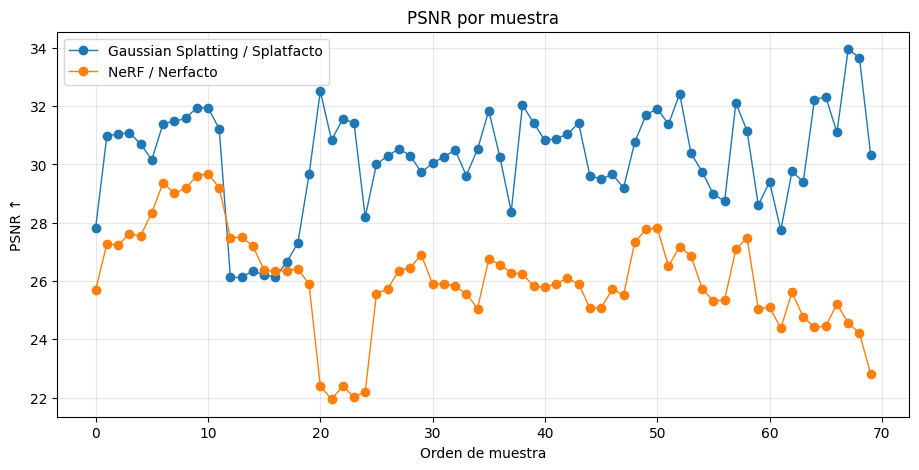

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/benchmark_outputs/psnr_curve.png


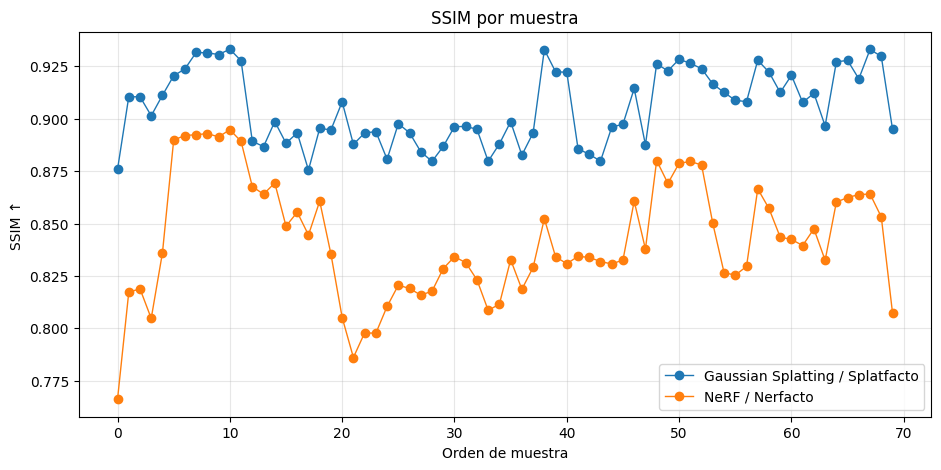

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/benchmark_outputs/ssim_curve.png


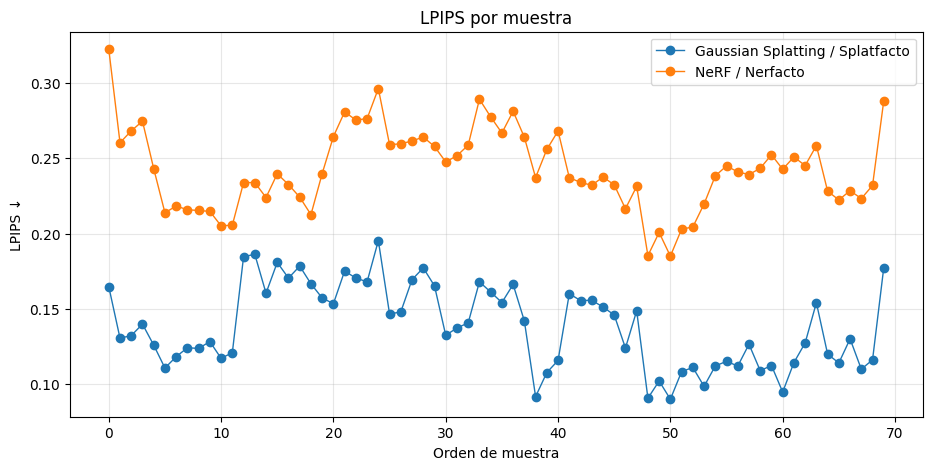

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/benchmark_outputs/lpips_curve.png


In [26]:
def plot_metric(metric, title, ylabel):
    plt.figure(figsize=(11, 5))
    for method, sub in df_metrics.groupby("method"):
        sub = sub.sort_values("sample_order")
        plt.plot(sub["sample_order"], sub[metric], marker="o", linewidth=1, label=method)
    plt.title(title)
    plt.xlabel("Orden de muestra")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    out = OUTPUT_DIR / f"{metric}_curve.png"
    plt.savefig(out, dpi=160, bbox_inches="tight")
    plt.show()
    print("Guardado:", out)

plot_metric("psnr", "PSNR por muestra", "PSNR ↑")
plot_metric("ssim", "SSIM por muestra", "SSIM ↑")
plot_metric("lpips", "LPIPS por muestra", "LPIPS ↓")

/tmp/ipykernel_8098/4233105257.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


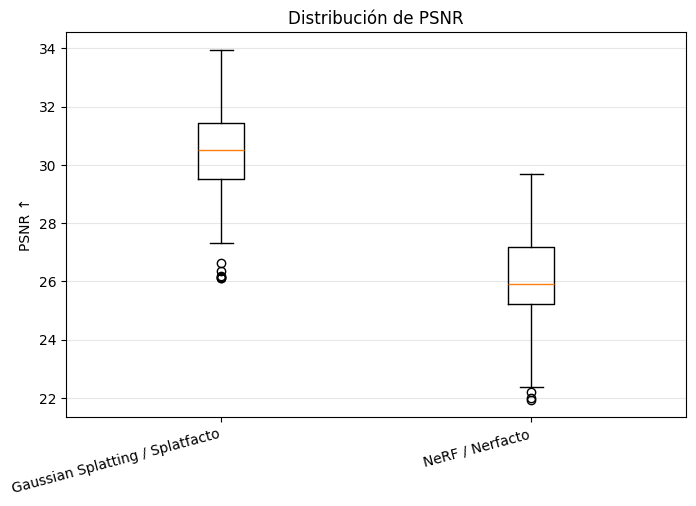

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/benchmark_outputs/psnr_boxplot.png


/tmp/ipykernel_8098/4233105257.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


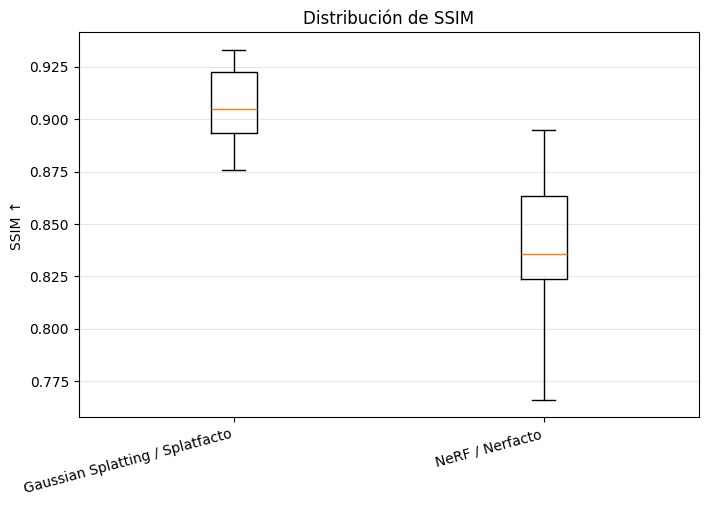

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/benchmark_outputs/ssim_boxplot.png


/tmp/ipykernel_8098/4233105257.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


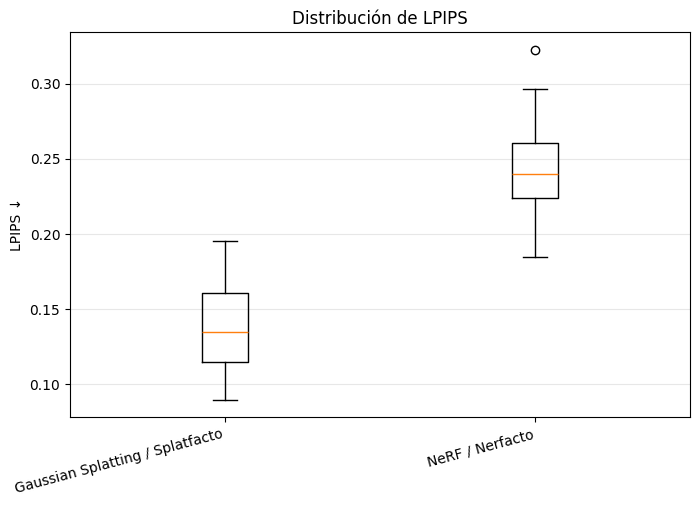

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/benchmark_outputs/lpips_boxplot.png


In [27]:
for metric, ylabel in [("psnr", "PSNR ↑"), ("ssim", "SSIM ↑"), ("lpips", "LPIPS ↓")]:
    plt.figure(figsize=(8, 5))
    grouped = list(df_metrics.groupby("method"))
    data = [sub[metric].values for _, sub in grouped]
    labels = [method for method, _ in grouped]
    plt.boxplot(data, labels=labels)
    plt.title(f"Distribución de {metric.upper()}")
    plt.ylabel(ylabel)
    plt.xticks(rotation=15, ha="right")
    plt.grid(True, axis="y", alpha=0.3)
    out = OUTPUT_DIR / f"{metric}_boxplot.png"
    plt.savefig(out, dpi=160, bbox_inches="tight")
    plt.show()
    print("Guardado:", out)

## 9. Grilla visual comparativa

Columnas:

```text
Original | Splatfacto | Nerfacto
```

In [28]:
def imread_uint8(path):
    img = Image.open(path).convert("RGB")
    if RESIZE_TO is not None:
        img = img.resize(RESIZE_TO, Image.BICUBIC)
    arr = np.asarray(img)
    if CENTER_CROP_TO is not None:
        crop_w, crop_h = CENTER_CROP_TO
        h, w = arr.shape[:2]
        crop_w = min(crop_w, w)
        crop_h = min(crop_h, h)
        x0 = (w - crop_w) // 2
        y0 = (h - crop_h) // 2
        arr = arr[y0:y0+crop_h, x0:x0+crop_w]
    return arr

def make_comparison_grid(max_rows=8):
    if max_rows >= len(sampled_pairs):
        chosen = list(range(len(sampled_pairs)))
    else:
        chosen = np.linspace(0, len(sampled_pairs) - 1, max_rows).round().astype(int).tolist()

    rows = []
    for i in chosen:
        row = sampled_pairs[i]
        original = imread_uint8(row["original_path"])
        splat = imread_uint8(row["splatfacto_path"])
        nerf = imread_uint8(row["nerfacto_path"])

        h = min(original.shape[0], splat.shape[0], nerf.shape[0])
        w = min(original.shape[1], splat.shape[1], nerf.shape[1])
        rows.append(np.concatenate([original[:h, :w], splat[:h, :w], nerf[:h, :w]], axis=1))

    grid = np.concatenate(rows, axis=0)
    out = OUTPUT_DIR / "comparison_grid_original_splatfacto_nerfacto.png"
    Image.fromarray(grid).save(out)

    plt.figure(figsize=(16, max(4, len(rows) * 3)))
    plt.imshow(grid)
    plt.axis("off")
    plt.title("Columnas: Original | Splatfacto | Nerfacto")
    plt.show()

    print("Guardado:", out)

make_comparison_grid(max_rows=8)

Output hidden; open in https://colab.research.google.com to view.

## 10. Mejores y peores casos

In [29]:
def report_best_worst(metric, higher_is_better=True, k=5):
    print(f"\n===== {metric.upper()} =====")
    for method, sub in df_metrics.groupby("method"):
        best = sub.sort_values(metric, ascending=not higher_is_better).head(k)
        worst = sub.sort_values(metric, ascending=higher_is_better).head(k)

        print(f"\n{method}")
        print("Mejores:")
        print(best[["sample_order", "pair_index", "original_name", "pred_name", metric]].to_string(index=False))
        print("\nPeores:")
        print(worst[["sample_order", "pair_index", "original_name", "pred_name", metric]].to_string(index=False))

report_best_worst("psnr", higher_is_better=True)
report_best_worst("ssim", higher_is_better=True)
report_best_worst("lpips", higher_is_better=False)


===== PSNR =====

Gaussian Splatting / Splatfacto
Mejores:
 sample_order  pair_index   original_name       pred_name      psnr
           67         618 frame_00619.jpg frame_00687.jpg 33.951212
           68         623 frame_00624.jpg frame_00692.jpg 33.660078
           20         159 frame_00160.jpg frame_00177.jpg 32.511477
           52         432 frame_00433.jpg frame_00480.jpg 32.425211
           65         604 frame_00605.jpg frame_00671.jpg 32.318734

Peores:
 sample_order  pair_index   original_name       pred_name      psnr
           13          95 frame_00096.jpg frame_00106.jpg 26.123649
           12          94 frame_00095.jpg frame_00105.jpg 26.127157
           16         104 frame_00105.jpg frame_00116.jpg 26.143537
           15         103 frame_00104.jpg frame_00115.jpg 26.203373
           14          99 frame_00100.jpg frame_00110.jpg 26.351362

NeRF / Nerfacto
Mejores:
 sample_order  pair_index   original_name       pred_name      psnr
           10        

## 11. Grillas de peores casos LPIPS

Sirven para discusión cualitativa.

In [30]:
def make_worst_lpips_grid(method_label, k=6):
    sub = df_metrics[df_metrics["method"] == method_label].copy()
    sub = sub.sort_values("lpips", ascending=False).head(k)

    rows = []
    for _, r in sub.iterrows():
        original = imread_uint8(r["original_path"])
        pred = imread_uint8(r["pred_path"])

        h = min(original.shape[0], pred.shape[0])
        w = min(original.shape[1], pred.shape[1])
        rows.append(np.concatenate([original[:h, :w], pred[:h, :w]], axis=1))

    grid = np.concatenate(rows, axis=0)
    safe_name = re.sub(r"[^a-zA-Z0-9]+", "_", method_label.lower()).strip("_")
    out = OUTPUT_DIR / f"worst_lpips_{safe_name}.png"
    Image.fromarray(grid).save(out)

    plt.figure(figsize=(12, max(4, len(rows) * 3)))
    plt.imshow(grid)
    plt.axis("off")
    plt.title(f"Peores casos LPIPS — Original | {method_label}")
    plt.show()

    print("Guardado:", out)

for method_label in df_metrics["method"].unique():
    make_worst_lpips_grid(method_label, k=6)

Output hidden; open in https://colab.research.google.com to view.

In [31]:
import shutil
from pathlib import Path
import pandas as pd
import numpy as np
from datetime import datetime

from reportlab.lib import colors
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_LEFT, TA_CENTER
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    Image as RLImage,
    PageBreak,
)
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfbase import pdfmetrics


# ------------------------------------------------------------
# Rutas
# ------------------------------------------------------------

PDF_PATH = PROJECT_DIR / "benchmark_report.pdf"
PDF_COPY_PATH = OUTPUT_DIR / "benchmark_report.pdf"

summary_path = OUTPUT_DIR / "metrics_summary.csv"
framewise_path = OUTPUT_DIR / "metrics_framewise.csv"
sample_manifest_path = OUTPUT_DIR / "sampled_pairs_manifest.csv"

summary_report = pd.read_csv(summary_path) if summary_path.exists() else summary.copy()
framewise_report = pd.read_csv(framewise_path) if framewise_path.exists() else df_metrics.copy()
sample_manifest_report = pd.read_csv(sample_manifest_path) if sample_manifest_path.exists() else sampled_df.copy()

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def clean_text(value):
    if pd.isna(value):
        return ""
    return str(value).replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")

def df_for_pdf(df, max_rows=None, round_digits=4):
    out = df.copy()

    if max_rows is not None:
        out = out.head(max_rows)

    for col in out.columns:
        if pd.api.types.is_float_dtype(out[col]):
            out[col] = out[col].round(round_digits)

    data = [list(out.columns)] + out.astype(str).values.tolist()
    return data

def make_table(df, max_rows=None, font_size=7, header_bg=colors.lightgrey):
    data = df_for_pdf(df, max_rows=max_rows)
    data = [[clean_text(cell) for cell in row] for row in data]

    table = Table(data, repeatRows=1)
    table.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), header_bg),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.black),
        ("GRID", (0, 0), (-1, -1), 0.25, colors.grey),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTNAME", (0, 1), (-1, -1), "Helvetica"),
        ("FONTSIZE", (0, 0), (-1, -1), font_size),
        ("VALIGN", (0, 0), (-1, -1), "TOP"),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.whitesmoke]),
    ]))
    return table

def image_if_exists(path, max_width=17*cm, max_height=20*cm):
    path = Path(path)
    if not path.exists():
        return None

    img = RLImage(str(path))
    iw, ih = img.imageWidth, img.imageHeight

    scale = min(max_width / iw, max_height / ih)
    img.drawWidth = iw * scale
    img.drawHeight = ih * scale
    return img

def metric_direction(metric_name):
    if metric_name.lower() in ["psnr", "ssim"]:
        return "max"
    return "min"

def get_best_method(summary_df, metric):
    col = f"{metric}_mean"
    if col not in summary_df.columns or len(summary_df) == 0:
        return None

    if metric_direction(metric) == "max":
        row = summary_df.sort_values(col, ascending=False).iloc[0]
    else:
        row = summary_df.sort_values(col, ascending=True).iloc[0]

    return row["method"], row[col]

def get_top_cases(df_metrics, method_label, metric, k=5, best=True):
    sub = df_metrics[df_metrics["method"] == method_label].copy()

    if len(sub) == 0:
        return sub

    if metric_direction(metric) == "max":
        ascending = not best
    else:
        ascending = best

    cols = [
        c for c in [
            "sample_order",
            "pair_index",
            "original_name",
            "pred_name",
            metric
        ]
        if c in sub.columns
    ]

    return sub.sort_values(metric, ascending=ascending).head(k)[cols]


# ------------------------------------------------------------
# Estilos
# ------------------------------------------------------------

styles = getSampleStyleSheet()

styles.add(ParagraphStyle(
    name="TitleCenter",
    parent=styles["Title"],
    alignment=TA_CENTER,
    fontSize=20,
    leading=24,
    spaceAfter=18,
))

styles.add(ParagraphStyle(
    name="SectionTitle",
    parent=styles["Heading1"],
    fontSize=15,
    leading=18,
    spaceBefore=12,
    spaceAfter=8,
))

styles.add(ParagraphStyle(
    name="SubsectionTitle",
    parent=styles["Heading2"],
    fontSize=12,
    leading=15,
    spaceBefore=10,
    spaceAfter=6,
))

styles.add(ParagraphStyle(
    name="BodyCustom",
    parent=styles["BodyText"],
    fontSize=9,
    leading=12,
    spaceAfter=6,
))

styles.add(ParagraphStyle(
    name="Small",
    parent=styles["BodyText"],
    fontSize=7,
    leading=9,
    spaceAfter=4,
))


# ------------------------------------------------------------
# Datos generales
# ------------------------------------------------------------

n_original = len(original_imgs) if "original_imgs" in globals() else None
n_splat = len(splat_imgs) if "splat_imgs" in globals() else None
n_nerf = len(nerf_imgs) if "nerf_imgs" in globals() else None

n_pairs = len(pairs_df) if "pairs_df" in globals() else None
n_eval = len(sampled_df) if "sampled_df" in globals() else None

best_psnr = get_best_method(summary_report, "psnr")
best_ssim = get_best_method(summary_report, "ssim")
best_lpips = get_best_method(summary_report, "lpips")


# ------------------------------------------------------------
# Construcción del PDF
# ------------------------------------------------------------

doc = SimpleDocTemplate(
    str(PDF_PATH),
    pagesize=A4,
    rightMargin=1.5*cm,
    leftMargin=1.5*cm,
    topMargin=1.5*cm,
    bottomMargin=1.5*cm,
)

story = []

story.append(Paragraph("Informe de benchmark", styles["TitleCenter"]))
story.append(Paragraph("Original vs Gaussian Splatting / Splatfacto vs NeRF / Nerfacto", styles["TitleCenter"]))
story.append(Spacer(1, 0.5*cm))
story.append(Paragraph(f"Fecha de generación: {datetime.now().strftime('%Y-%m-%d %H:%M')}", styles["BodyCustom"]))
story.append(Spacer(1, 0.5*cm))

story.append(Paragraph("1. Objetivo", styles["SectionTitle"]))
story.append(Paragraph(
    "Este informe resume la evaluación cuantitativa y cualitativa de los renders generados "
    "con Gaussian Splatting / Splatfacto y NeRF / Nerfacto, comparándolos contra imágenes "
    "originales del dataset. Las métricas utilizadas fueron PSNR, SSIM, LPIPS, MSE y MAE.",
    styles["BodyCustom"]
))

story.append(Paragraph("2. Configuración experimental", styles["SectionTitle"]))

config_df = pd.DataFrame([
    ["Proyecto", str(PROJECT_DIR)],
    ["Resultados", str(OUTPUT_DIR)],
    ["Dataset original", str(ORIGINAL_DIR)],
    ["Dataset Splatfacto", str(SPLATFACTO_DIR)],
    ["Dataset Nerfacto", str(NERFACTO_DIR)],
    ["Imágenes originales detectadas", n_original],
    ["Imágenes Splatfacto detectadas", n_splat],
    ["Imágenes Nerfacto detectadas", n_nerf],
    ["Pares disponibles", n_pairs],
    ["Muestra evaluada", n_eval],
    ["Modo de muestreo", SAMPLING_MODE],
    ["Semilla aleatoria", RANDOM_SEED],
    ["Emparejamiento", MATCH_BY],
    ["Resolución normalizada", RESIZE_TO],
    ["Recorte central", CENTER_CROP_TO],
], columns=["Parámetro", "Valor"])

story.append(make_table(config_df, font_size=5))
story.append(Spacer(1, 0.4*cm))

story.append(Paragraph("3. Resumen de métricas", styles["SectionTitle"]))
story.append(Paragraph(
    "PSNR y SSIM se interpretan como mejores cuando son más altos. LPIPS, MSE y MAE se "
    "interpretan como mejores cuando son más bajos.",
    styles["BodyCustom"]
))
story.append(make_table(summary_report.round(4), font_size=5))
story.append(Spacer(1, 0.4*cm))

story.append(Paragraph("4. Lectura automática inicial", styles["SectionTitle"]))

auto_lines = []
if best_psnr:
    auto_lines.append(f"Mejor método en PSNR: {best_psnr[0]} ({best_psnr[1]:.4f}).")
if best_ssim:
    auto_lines.append(f"Mejor método en SSIM: {best_ssim[0]} ({best_ssim[1]:.4f}).")
if best_lpips:
    auto_lines.append(f"Mejor método en LPIPS: {best_lpips[0]} ({best_lpips[1]:.4f}).")

for line in auto_lines:
    story.append(Paragraph(line, styles["BodyCustom"]))

story.append(Paragraph(
    "Estas métricas deben complementarse con inspección visual, porque pequeñas diferencias "
    "de cámara, exposición, nitidez o alineación pueden modificar los valores numéricos.",
    styles["BodyCustom"]
))

story.append(PageBreak())

# ------------------------------------------------------------
# Gráficos principales
# ------------------------------------------------------------

story.append(Paragraph("5. Gráficos principales", styles["SectionTitle"]))

graph_groups = [
    ("Curva PSNR", OUTPUT_DIR / "psnr_curve.png"),
    ("Curva SSIM", OUTPUT_DIR / "ssim_curve.png"),
    ("Curva LPIPS", OUTPUT_DIR / "lpips_curve.png"),
    ("Boxplot PSNR", OUTPUT_DIR / "psnr_boxplot.png"),
    ("Boxplot SSIM", OUTPUT_DIR / "ssim_boxplot.png"),
    ("Boxplot LPIPS", OUTPUT_DIR / "lpips_boxplot.png"),
]

for title, path in graph_groups:
    img = image_if_exists(path, max_width=16*cm, max_height=10*cm)
    if img is not None:
        story.append(Paragraph(title, styles["SubsectionTitle"]))
        story.append(img)
        story.append(Spacer(1, 0.3*cm))

story.append(PageBreak())

# ------------------------------------------------------------
# Grilla visual
# ------------------------------------------------------------

story.append(Paragraph("6. Comparación visual", styles["SectionTitle"]))
story.append(Paragraph(
    "La siguiente grilla permite inspeccionar visualmente la correspondencia entre las imágenes "
    "originales y los renders de Splatfacto y Nerfacto.",
    styles["BodyCustom"]
))

grid_path = OUTPUT_DIR / "comparison_grid_original_splatfacto_nerfacto.png"
grid_img = image_if_exists(grid_path, max_width=18*cm, max_height=23*cm)

if grid_img is not None:
    story.append(grid_img)
else:
    story.append(Paragraph("No se encontró la grilla comparativa.", styles["BodyCustom"]))

story.append(PageBreak())

# ------------------------------------------------------------
# Mejores y peores casos
# ------------------------------------------------------------

story.append(Paragraph("7. Mejores y peores casos", styles["SectionTitle"]))

for method in summary_report["method"].tolist():
    story.append(Paragraph(method, styles["SubsectionTitle"]))

    best_psnr_cases = get_top_cases(framewise_report, method, "psnr", k=5, best=True)
    worst_lpips_cases = get_top_cases(framewise_report, method, "lpips", k=5, best=False)

    story.append(Paragraph("Mejores casos por PSNR", styles["BodyCustom"]))
    story.append(make_table(best_psnr_cases.round(4), font_size=5))
    story.append(Spacer(1, 0.25*cm))

    story.append(Paragraph("Peores casos por LPIPS", styles["BodyCustom"]))
    story.append(make_table(worst_lpips_cases.round(4), font_size=5))
    story.append(Spacer(1, 0.4*cm))

story.append(PageBreak())

# ------------------------------------------------------------
# Peores casos visuales LPIPS
# ------------------------------------------------------------

story.append(Paragraph("8. Peores casos visuales por LPIPS", styles["SectionTitle"]))

possible_worst_imgs = [
    OUTPUT_DIR / "worst_lpips_gaussian_splatting_splatfacto.png",
    OUTPUT_DIR / "worst_lpips_gaussian_splatting_splatfacto_.png",
    OUTPUT_DIR / "worst_lpips_ne_rf_nerfacto.png",
    OUTPUT_DIR / "worst_lpips_nerf_nerfacto.png",
    OUTPUT_DIR / "worst_lpips_ne_rf_nerfacto_.png",
]

found_any = False

for path in possible_worst_imgs:
    img = image_if_exists(path, max_width=17*cm, max_height=12*cm)
    if img is not None:
        found_any = True
        story.append(Paragraph(path.name, styles["SubsectionTitle"]))
        story.append(img)
        story.append(Spacer(1, 0.3*cm))

if not found_any:
    story.append(Paragraph("No se encontraron grillas de peores casos LPIPS.", styles["BodyCustom"]))

story.append(PageBreak())

# ------------------------------------------------------------
# Muestra evaluada
# ------------------------------------------------------------

story.append(Paragraph("9. Muestra evaluada", styles["SectionTitle"]))
story.append(Paragraph(
    "La siguiente tabla muestra los primeros pares utilizados en la muestra evaluada.",
    styles["BodyCustom"]
))

sample_cols = [
    c for c in [
        "sample_order",
        "pair_index",
        "original_name",
        "splatfacto_name",
        "nerfacto_name"
    ]
    if c in sample_manifest_report.columns
]

if len(sample_cols) > 0:
    story.append(make_table(sample_manifest_report[sample_cols].head(20), font_size=5))
else:
    story.append(make_table(sample_manifest_report.head(20), font_size=5))

story.append(Spacer(1, 0.4*cm))

story.append(Paragraph("10. Conclusión preliminar", styles["SectionTitle"]))
story.append(Paragraph(
    "El benchmark permite comparar la fidelidad visual de Splatfacto y Nerfacto frente al "
    "dataset original. La lectura final debe considerar tanto las métricas cuantitativas como "
    "la inspección visual de los casos representativos. Para una evaluación arquitectónica "
    "integral, estos resultados deberían complementarse con una comparación geométrica separada "
    "de la nube de puntos fotogramétrica.",
    styles["BodyCustom"]
))

# ------------------------------------------------------------
# Construir PDF
# ------------------------------------------------------------

doc.build(story)

# Copiar también a benchmark_outputs
shutil.copy2(PDF_PATH, PDF_COPY_PATH)

print("PDF generado en:")
print(" -", PDF_PATH)
print(" -", PDF_COPY_PATH)


PDF generado en:
 - /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/benchmark_report.pdf
 - /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/benchmark_outputs/benchmark_report.pdf


In [32]:
# ============================================================
# 14C. Descargar PDF
# ============================================================

from google.colab import files

files.download(str(PROJECT_DIR / "benchmark_report.pdf"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Exportar resultados

Los resultados quedan en:

```text
/colab/benchmark_outputs
```

También se descarga un ZIP.

In [ ]:
# ============================================================
# Exportar resultados actualizados
# ============================================================

zip_path = PROJECT_DIR / "benchmark_outputs.zip"

if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(str(zip_path).replace(".zip", ""), "zip", OUTPUT_DIR)

print("Resultados guardados en:", OUTPUT_DIR)
print("ZIP:", zip_path)

from google.colab import files
files.download(str(zip_path))

## 13. Texto metodológico para tesis

```text
La evaluación cuantitativa se realizó sobre una muestra reproducible de frames, comparando las imágenes originales contra los renders generados por Splatfacto y Nerfacto. Se utilizaron PSNR, SSIM y LPIPS para medir fidelidad píxel a píxel, similitud estructural y similitud perceptual. Los resultados se complementan con una inspección cualitativa de mejores y peores casos, ya que las métricas pueden penalizar pequeñas diferencias de alineación, exposición o trayectoria de cámara.
```